In [59]:
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 

In [60]:
from torchvision.datasets import CIFAR10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)  
CIFAR10_STD = (0.2023, 0.1994, 0.2010)


# Apply in your data loader with torchvision.transforms
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

train_dataset = CIFAR10(
    root="./datasets",
    train=True,
    download=True,
    transform=transform
)

test_dataset = CIFAR10(
    root="./datasets",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

print(torch.__version__)
print(torch.version.cuda)

cuda
2.12.0+cu130
13.0


In [62]:
import torch
import torch.nn as nn

class CNN_(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3)
        self.maxpool = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(in_channels=6, out_channels=8, kernel_size=3)
        self.conv4 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3)
        self.batchnorm1 = nn.BatchNorm2d(8)
        self.conv5 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3)
        self.conv6 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3)
        self.dropoutConv6 = nn.Dropout(p=0.3)
        self.batchnorm2 = nn.BatchNorm2d(16)


        self.fc1 = nn.Linear(32, 32)
        self.dropoutFC1 = nn.Dropout(p = 0.4)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.maxpool(x)
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.batchnorm1(x)
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x = self.dropoutConv6(x)
        x = self.batchnorm2(x)

        x = torch.flatten(x, start_dim=1)
        x = self.dropoutFC1(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)   

        return x


model = CNN_()

In [63]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

def accuracy(loader): 
    model.eval()
    
    correct = 0 ; total = 0 

    with torch.no_grad():
        for img, label in loader: 

            img = img.to(device)
            label = label.to(device)

            yhat = model(img)
            yhat = torch.argmax(yhat, dim=1)
            correct += (label == yhat).sum().item()

            total += len(yhat)

        return 100 * (correct/total)



In [64]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle=True)


In [65]:
import time 

epochs = 50
loss_rec = []
accuracy_rec_test = []
accuracy_rec_train = []



model = model.to(device)

for i in range(epochs): 

    model.train()

    s = time.time()
    device = 'cuda'
    current_loss = 0 
    for img, label in train_loader:
        img = img.to(device)
        label = label.to(device)
        yhat = model(img)
        optimizer.zero_grad()
        loss = loss_fn(yhat, label)
        loss.backward()
        optimizer.step()

        current_loss += loss.item()
    current_loss = current_loss/len(train_loader)

    accuracy_test = accuracy(test_loader)
    accuracy_train = accuracy(train_loader)

    accuracy_rec_train.append(accuracy_train)
    accuracy_rec_test.append(accuracy_test)
    loss_rec.append(current_loss) 
    end = time.time() - s
    print(f"Epoch : {i+1}  || Loss : {loss:.2f} || Accuracy ( Train dataset ) : {accuracy_train:.2f} || Accuracy ( Test dataset ): {accuracy_test:.2f} || Time taken : {end:.2f}s")



RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x576 and 32x32)

In [ ]:
accuracy_ = accuracy(test_loader)
print(accuracy_)

41.79


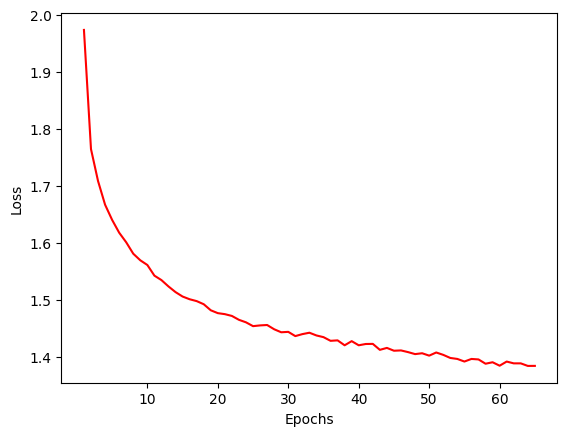

In [ ]:
import numpy as np 
ep = np.arange(250) + 1

plt.plot(ep, loss_rec, color='red')
plt.xticks(ep[ep%10 == 0])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

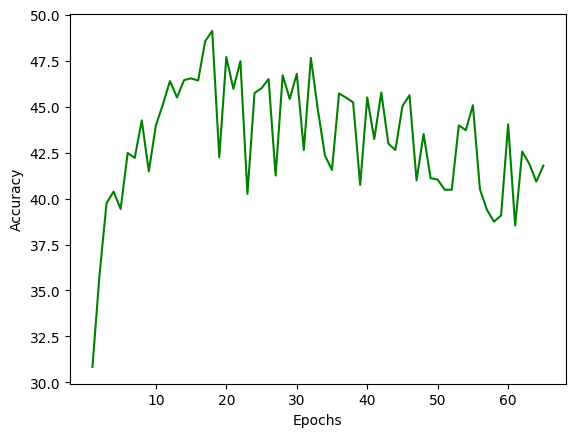

In [ ]:
plt.plot(ep, accuracy_rec_test, color='green')
plt.xticks(ep[ep%10 == 0])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import sklearn 
from sklearn.metrics import confusion_matrix

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_hat = []
y_true = []

with torch.no_grad(): 
    for images, labels in test_loader: 

        images = images.to("cuda")
        labels = labels.to("cuda")

        y_hat_batch = torch.argmax(model(images), dim=1)
        y_true_batch = labels 

        y_hat.extend(y_hat_batch.cpu().numpy())
        y_true.extend(y_true_batch.cpu().numpy())




cnf_mat = confusion_matrix(y_pred=y_hat , y_true=y_true)

In [ ]:
cnf_mat

array([[749,   0,  14,  97,   7,   1,   1,   9,   1, 121],
       [ 84,  32,   0,  19,   4,   0,   0,   9,   3, 849],
       [168,   0, 114, 441, 188,  21,  17,  23,   0,  28],
       [ 61,   0,   3, 683,  58,  74,  19,  53,   0,  49],
       [ 65,   0,   7, 260, 549,   3,  19,  74,   0,  23],
       [ 22,   0,   9, 594,  53, 234,   2,  69,   0,  17],
       [ 32,   1,  15, 331, 160,   1, 418,   5,   0,  37],
       [ 21,   0,   1, 245, 128,  45,   0, 523,   0,  37],
       [773,   2,   3,  43,   0,   0,   1,   1,  27, 150],
       [ 53,   2,   0,  39,  15,   0,   0,  41,   0, 850]])

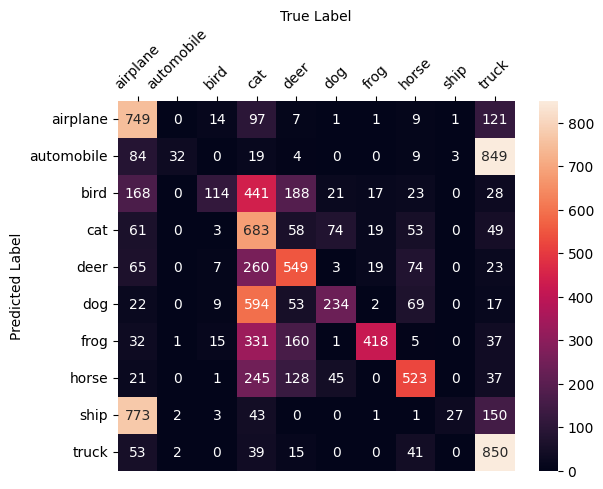

In [ ]:
import seaborn as sns 

ax = sns.heatmap(cnf_mat,xticklabels=classes, yticklabels=classes, annot=True, fmt='d')
plt.ylabel("Predicted Label")
plt.xlabel("True Label")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [ ]:
print("Loss : ", loss_rec )
print("accuracy_rec_test", accuracy_rec_test )
print("accuracy_rec_train", accuracy_rec_train) 

Loss :  [1.9733818810614174, 1.7644607491810302, 1.7084854132379108, 1.6669926933010522, 1.6403606744373547, 1.6179482176175812, 1.6010936692242732, 1.5810950392347467, 1.5695356322676324, 1.5613351474942454, 1.5426653852243253, 1.5348537158783135, 1.5237198458303272, 1.5137986418841136, 1.5060409301382196, 1.5012838694140733, 1.498024271119891, 1.4925718228225513, 1.4819487240308387, 1.4769305661511238, 1.4751638167959344, 1.4720284278740359, 1.4652278740387743, 1.460836918381474, 1.4541413334324538, 1.4554291148014995, 1.4561410587462014, 1.44867553918258, 1.443409331009516, 1.4441298889686993, 1.4366962408165798, 1.4401558288527876, 1.442606704466788, 1.43781061413343, 1.4348653213447318, 1.428423633203482, 1.4292110652874803, 1.4205849975576181, 1.4278383916601196, 1.420601751493371, 1.422855910437796, 1.423055512216085, 1.4126122322533747, 1.41600272097551, 1.4110590184436125, 1.4115725319708705, 1.4086382146686545, 1.405126304730125, 1.4066338025395522, 1.4024439914452145, 1.4079

In [ ]:
# ## Just for logging previous experiment logs 

# # # just relu 
# # Loss :  [1.7630162969269716, 1.4106459799782394, 1.2758248418645786, 1.167960738129628, 1.06969210452131, 0.9897516478815347, 0.9197347417969228, 0.8528001485273357, 0.7864529503428418, 0.7179696521033412, 0.6480985768234638, 0.5816262252724079, 0.5079043373808532, 0.4489042817441094, 0.38373450502334044, 0.34021960421825004, 0.28164710584656355, 0.25091171041702676, 0.2125013108077028, 0.19695333892579578, 0.17668300554813707, 0.1527269470703114, 0.1478262115067438, 0.13504242270951494, 0.11384072440230976, 0.11640082723210993, 0.12277371076571629, 0.10291825356069104, 0.11503141756822138, 0.10200155415343563, 0.08691600917736092, 0.09854868434124228, 0.0872190318688455, 0.08171818651052912, 0.09472266458930052, 0.08503509360922934, 0.08337012704347482, 0.09086490274124714, 0.0641659684848431, 0.0900022044180609, 0.07296742489823448, 0.07115212400995262, 0.0757642543509655, 0.07646685168581784, 0.06894935449332837, 0.07642316213562428, 0.06285541049381027, 0.07400642614647904, 0.06535760116177763, 0.057112597946442016]
# # accuracy_rec_test [45.53, 52.01, 54.25, 57.550000000000004, 58.74, 58.76, 60.99, 60.160000000000004, 59.91, 58.550000000000004, 57.15, 58.3, 57.03, 57.06, 56.47, 55.800000000000004, 55.95, 55.75, 54.279999999999994, 54.169999999999995, 54.690000000000005, 54.56999999999999, 54.37, 53.94, 54.99000000000001, 53.49, 53.800000000000004, 54.02, 53.89000000000001, 52.93, 54.39000000000001, 53.800000000000004, 53.5, 53.580000000000005, 53.61, 53.790000000000006, 53.71, 53.38, 53.769999999999996, 53.480000000000004, 53.38, 53.49, 53.15, 53.239999999999995, 53.66, 53.53, 54.35, 53.03, 52.92, 53.2]
# # accuracy_rec_train [46.53, 53.628, 57.858, 62.35000000000001, 65.06, 67.632, 72.636, 73.416, 76.244, 77.986, 79.324, 84.572, 85.19, 89.71000000000001, 91.488, 91.666, 93.768, 94.086, 94.71199999999999, 93.672, 95.336, 95.422, 94.158, 96.788, 97.832, 95.17999999999999, 95.192, 97.478, 97.81800000000001, 96.258, 97.52, 96.048, 98.292, 97.512, 96.88799999999999, 97.70400000000001, 97.828, 97.72999999999999, 97.328, 97.142, 97.75399999999999, 98.194, 98.14399999999999, 97.89, 98.30799999999999, 97.76599999999999, 98.734, 97.19200000000001, 97.328, 98.738]

# ### Added max pooling ( better generalization )

# #Loss :  [1.9437604415447205, 1.6998907611193255, 1.6116020062085612, 1.534323692474219, 1.4757873896137832, 1.432642532431561, 1.3920701278749938, 1.3676891839107894, 1.343018277298154, 1.3236336861272602, 1.3061835250586196, 1.2920786031829121, 1.2832510847874614, 1.2691274783038118, 1.2580676920273726, 1.2437384099606663, 1.2332604798819402, 1.22706578157442, 1.213877312133989, 1.2043740436091752, 1.1947843716729938, 1.1859196342928024, 1.1779477568843482, 1.1685349801769647, 1.1629281402243983, 1.1572760027235427, 1.1486603219795715, 1.141713965198268, 1.1332581793255818, 1.132342106088653, 1.1267156922603812, 1.1210164971211378, 1.1123479952287796, 1.1119282024595745, 1.109661290941336, 1.1022577179819726, 1.1028667837000259, 1.0936494848459883, 1.0928036141426056, 1.091746328736815, 1.0862061143531214, 1.0844068677376604, 1.0792152192586524, 1.0796103536168022, 1.068844326621736, 1.0742599628770444, 1.0656551049493463, 1.0654303059553552, 1.0635000612882093, 1.0584498707900571]
# # accuracy_rec_test [34.75, 39.86, 42.199999999999996, 45.82, 46.11, 47.77, 49.480000000000004, 49.75, 52.1, 51.959999999999994, 52.38, 53.800000000000004, 53.43, 53.2, 55.2, 54.94, 55.669999999999995, 55.54, 55.55, 56.58, 57.03, 55.769999999999996, 55.88999999999999, 56.86, 57.42, 57.16, 57.269999999999996, 58.8, 57.63, 58.660000000000004, 57.64, 58.709999999999994, 58.099999999999994, 59.28, 57.589999999999996, 58.3, 59.85, 59.48, 59.79, 59.29, 59.17, 57.24, 58.64, 60.370000000000005, 60.07, 59.85, 59.03, 60.040000000000006, 60.58, 59.11]
# # accuracy_rec_train [34.476, 39.864, 42.138, 45.873999999999995, 46.272000000000006, 48.892, 49.686, 50.583999999999996, 52.769999999999996, 52.686, 53.442, 54.54, 54.018, 53.738, 56.006, 55.891999999999996, 56.762, 56.858, 56.69800000000001, 57.654, 58.072, 57.635999999999996, 57.428000000000004, 58.821999999999996, 58.814, 58.794000000000004, 58.556, 60.01800000000001, 59.128, 60.040000000000006, 59.419999999999995, 60.394000000000005, 59.78, 61.25000000000001, 59.038000000000004, 59.86, 61.696, 61.318, 61.297999999999995, 61.228, 61.0, 59.51, 60.738, 61.739999999999995, 61.870000000000005, 61.99400000000001, 60.907999999999994, 62.486, 62.58200000000001, 61.366]

# # Added dropout after conv6 and fc1 
# # Loss :  [2.0482705543413187, 1.8820746009002256, 1.829264990356572, 1.7873757470904104, 1.7488681873702028, 1.7176857543418476, 1.6807624100114378, 1.646021222062123, 1.6216484073482815, 1.6038313248883123, 1.5890331612828443, 1.5711704893490237, 1.562527363562523, 1.5503319259494772, 1.5420438132017775, 1.5263995137970772, 1.516191902367965, 1.5144411496189245, 1.5020310608932124, 1.4983504574622035, 1.4868180285329404, 1.478759737728197, 1.4727534077051656, 1.4743154859908707, 1.460977562705574, 1.4591142995583126, 1.450262626113794, 1.4527779252023039, 1.4432331323623657, 1.440710933617009, 1.4306412770620087, 1.4290444483537503, 1.4306542632524923, 1.4263975865700667, 1.4213868853686107, 1.419279471535207, 1.414144843892978, 1.4110324442234186, 1.4137502750167457, 1.4086418654912574, 1.4043183907523484, 1.4022656473357353, 1.4048230085531463, 1.3988934169949778, 1.3957437676237063, 1.3987244071862888, 1.3911162111765283, 1.391184799963861, 1.3906699943420526, 1.3857598173648804]
# # accuracy_rec_test [19.52, 26.39, 28.999999999999996, 30.73, 32.42, 34.56, 33.14, 35.709999999999994, 34.089999999999996, 31.879999999999995, 31.66, 33.160000000000004, 33.08, 33.410000000000004, 30.8, 33.86, 30.8, 36.21, 32.56, 34.150000000000006, 34.760000000000005, 31.71, 35.49, 32.24, 33.68, 29.409999999999997, 34.77, 29.68, 35.38, 30.669999999999998, 31.96, 33.160000000000004, 28.74, 31.330000000000002, 32.29, 35.39, 29.609999999999996, 27.700000000000003, 30.270000000000003, 32.190000000000005, 33.51, 34.9, 28.96, 32.23, 34.48, 32.05, 34.07, 34.53, 31.6, 36.309999999999995]
# # accuracy_rec_train [19.328, 27.006000000000004, 29.067999999999998, 30.016, 32.128, 33.848, 32.774, 35.766, 34.056, 31.413999999999998, 31.635999999999996, 32.614, 32.566, 33.501999999999995, 30.328, 34.202, 30.734, 36.318, 32.212, 34.544000000000004, 35.089999999999996, 32.126, 35.476, 32.39, 33.794000000000004, 29.49, 35.454, 30.256, 35.948, 31.186000000000003, 32.542, 34.214, 29.554000000000002, 31.966, 32.885999999999996, 37.12, 30.414, 28.348000000000003, 31.569999999999997, 32.146, 34.514, 36.28, 29.712, 33.152, 36.018, 33.47, 34.64, 36.132, 32.208, 38.076]

# Batch normlization ( 65 epochs )

# Loss :  [1.9733818810614174, 1.7644607491810302, 1.7084854132379108, 1.6669926933010522, 1.6403606744373547, 1.6179482176175812, 1.6010936692242732, 1.5810950392347467, 1.5695356322676324, 1.5613351474942454, 1.5426653852243253, 1.5348537158783135, 1.5237198458303272, 1.5137986418841136, 1.5060409301382196, 1.5012838694140733, 1.498024271119891, 1.4925718228225513, 1.4819487240308387, 1.4769305661511238, 1.4751638167959344, 1.4720284278740359, 1.4652278740387743, 1.460836918381474, 1.4541413334324538, 1.4554291148014995, 1.4561410587462014, 1.44867553918258, 1.443409331009516, 1.4441298889686993, 1.4366962408165798, 1.4401558288527876, 1.442606704466788, 1.43781061413343, 1.4348653213447318, 1.428423633203482, 1.4292110652874803, 1.4205849975576181, 1.4278383916601196, 1.420601751493371, 1.422855910437796, 1.423055512216085, 1.4126122322533747, 1.41600272097551, 1.4110590184436125, 1.4115725319708705, 1.4086382146686545, 1.405126304730125, 1.4066338025395522, 1.4024439914452145, 1.407969667326154, 1.4037879565182854, 1.3983733338468216, 1.3966549936767734, 1.3921061699347728, 1.3966554554222186, 1.3958023717946104, 1.3882771585603504, 1.390855105941558, 1.384811893905825, 1.3920658140841042, 1.388914577186565, 1.3889017778894175, 1.384419178718801, 1.3844981884102687]
# accuracy_rec_test [30.84, 35.839999999999996, 39.75, 40.38, 39.43, 42.480000000000004, 42.21, 44.25, 41.48, 43.97, 45.12, 46.39, 45.5, 46.44, 46.54, 46.42, 48.559999999999995, 49.120000000000005, 42.25, 47.699999999999996, 45.97, 47.47, 40.25, 45.739999999999995, 46.0, 46.5, 41.25, 46.71, 45.42, 46.79, 42.64, 47.65, 44.81, 42.34, 41.56, 45.72, 45.49, 45.23, 40.739999999999995, 45.5, 43.24, 45.769999999999996, 42.99, 42.64, 45.03, 45.62, 40.99, 43.51, 41.11, 41.03, 40.48, 40.48, 43.980000000000004, 43.72, 45.08, 40.5, 39.379999999999995, 38.74, 39.08, 44.04, 38.53, 42.559999999999995, 41.89, 40.92, 41.79]
# accuracy_rec_train [30.702, 35.402, 39.75, 40.078, 39.410000000000004, 43.468, 42.768, 45.14, 41.583999999999996, 44.056, 44.914, 46.824, 45.678000000000004, 46.698, 47.092, 46.844, 49.292, 49.494, 42.902, 48.596000000000004, 46.867999999999995, 48.534, 41.254000000000005, 46.626, 46.982, 47.61, 42.46, 48.04, 46.29, 47.599999999999994, 43.656, 48.722, 45.550000000000004, 43.576, 42.071999999999996, 46.414, 46.69, 45.647999999999996, 41.874, 45.982, 44.352000000000004, 46.316, 43.712, 43.525999999999996, 45.784000000000006, 46.444, 42.314, 44.962, 41.926, 41.492000000000004, 41.221999999999994, 40.846, 44.794, 44.534, 46.166000000000004, 41.986000000000004, 40.598, 39.42, 40.111999999999995, 45.506, 39.272, 43.454, 42.446, 41.866, 43.053999999999995]


In [ ]:
# # Additional 50 epoch ( only if needed )
# for i in range(epochs):
#     s = time.time()
#     device = 'cuda'
#     current_loss = 0 
#     for img, label in train_loader:
#         img = img.to(device)
#         label = label.to(device)
#         yhat = model(img)
#         optimizer.zero_grad()
#         loss = loss_fn(yhat, label)
#         loss.backward()
#         optimizer.step()

#         current_loss += loss.item()
#     current_loss = current_loss/len(train_loader)

#     accuracy_test = accuracy(test_loader)
#     accuracy_train = accuracy(train_loader)

#     accuracy_rec_train.append(accuracy_train)
#     accuracy_rec_test.append(accuracy_test)
#     loss_rec.append(current_loss) 
#     end = time.time() - s
#     print(f"Epoch : {i+51}  || Loss : {loss} || Accuracy ( Train dataset ) : {accuracy_train} || Accuracy ( Test dataset ): {accuracy_test} || Time taken : {end}s")

In [ ]:
print(torch.cuda.is_available())
device = "cuda"

True
